# 🐍 3D Circular Corkscrew Snake Experiment: $\phi_t = \frac{\pi}{2}$

This experiment demonstrates **3D circular helical wave composition** on an articulated snake armature from the start ($t = 0.0\text{s}$):

### Mechanics:
1. **Track 1 (Horizontal Sine Wave along $Y$)**:
   - Lateral displacement: $u_y(s, t) = A \sin(k s - \omega t)$, starting at $t=0.0\text{s}$.
2. **Track 2 (Vertical Cosine Wave along $Z$ via $\phi_t = \frac{\pi}{2}$)**:
   - Vertical displacement: $u_z(s, t) = A \sin\left(k s - \omega t + \frac{\pi}{2}\right) = A \cos(k s - \omega t)$ via $90^\circ$ roll tilt $R_x(90^\circ)$.
   - Operates **from the start itself** (`start_offset = 0.0`).
3. **Result**:
   - Superposition creates a **pure circular orbit in the $Y-Z$ plane** ($u_y^2 + u_z^2 = A^2 = \text{const}$) that propagates forward along $X$.
   - The entire snake body continuously corkscrews in full $360^\circ$ circles across the entire duration!
4. **Mesh Deformation & Skinning**:
   - Continuous 60-ring segmented cylinder skin deformed via **Dual Quaternion Skinning (DQS)**.
5. **Interactive Viewports & Valid GLB Export**.

In [8]:
# 1. Imports and Workspace Setup
import sys, os
from pathlib import Path
sys.path.append(os.path.abspath('..'))

import numpy as np
import torch
import trimesh
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import plotly.graph_objects as go

from animgen.core.armature import Armature, Bone
from animgen.animation.animator import Animator, AnimationClip
from animgen.animation.wave import chain_wave_generator
from animgen.animation.kinematics import compute_forward_kinematics
from animgen.rigging.skinning import compute_auto_skin_weights
from animgen.io.glb_output import export_glb

print('AnimGen modules imported successfully!')

AnimGen modules imported successfully!


## 2. Build the Centered Armature & Segmented Mesh
Construct a 12-bone armature centered around the origin $(0, 0, 0)$ extending from $x = -2.0\text{m}$ to $x = +2.0\text{m}$, and a 60-ring segmented cylinder.

In [9]:
def create_segmented_cylinder(radius=0.18, height=4.0, num_rings=60, sections=20) -> trimesh.Trimesh:
    """Creates a cylinder with multiple cross-sectional rings centered around origin (x = -height/2 to +height/2)."""
    half_h = height / 2.0
    xs = np.linspace(-half_h, half_h, num_rings)
    thetas = np.linspace(0.0, 2 * np.pi, sections, endpoint=False)
    vertices = []
    for x in xs:
        for theta in thetas:
            vertices.append([x, radius * np.cos(theta), radius * np.sin(theta)])
    vertices = np.array(vertices, dtype=np.float32)
    faces = []
    for r in range(num_rings - 1):
        for s in range(sections):
            next_s = (s + 1) % sections
            v0 = r * sections + s
            v1 = r * sections + next_s
            v2 = (r + 1) * sections + next_s
            v3 = (r + 1) * sections + s
            faces.append([v0, v1, v2])
            faces.append([v0, v2, v3])
    c_start = len(vertices)
    vertices = np.vstack([vertices, [[-half_h, 0.0, 0.0]]])
    for s in range(sections):
        faces.append([c_start, (s + 1) % sections, s])
    c_end = len(vertices)
    vertices = np.vstack([vertices, [[half_h, 0.0, 0.0]]])
    end_offset = (num_rings - 1) * sections
    for s in range(sections):
        faces.append([c_end, end_offset + s, end_offset + ((s + 1) % sections)])
    return trimesh.Trimesh(vertices=vertices, faces=np.array(faces, dtype=np.int64))

num_bones = 12
total_length = 4.0
half_len = total_length / 2.0
bone_len = total_length / num_bones

# 1. Create connected bone hierarchy centered at origin
root = Bone(id='bone_0', head=(-half_len, 0.0, 0.0), tail=(-half_len + bone_len, 0.0, 0.0))
armature = Armature(root)
curr = root
for i in range(1, num_bones):
    tail_x = -half_len + (i + 1) * bone_len
    curr = armature.add_connected_bone(curr, tail=(tail_x, 0.0, 0.0))

# 2. Create segmented cylinder mesh
mesh = create_segmented_cylinder(radius=0.18, height=total_length, num_rings=60, sections=20)
skin_weights = compute_auto_skin_weights(mesh, armature)

print(f'Armature initialized with {len(armature.bones_list)} bones centered at origin.')
print(f'Segmented mesh: {len(mesh.vertices)} vertices across 60 rings, {len(mesh.faces)} faces.')

Armature initialized with 12 bones centered at origin.
Segmented mesh: 1202 vertices across 60 rings, 2400 faces.


## 3. Generate 3D Motion Clips (Travelling vs Standing Waves)
- **Clip 1 (`TravellingCircularSnake`)**: Travelling wave along Y ($\phi_t = 0.0$) + Travelling wave along Z ($\phi_t = \frac{\pi}{2}$, $90^\circ$ roll tilt).
- **Clip 2 (`StandingCircularSnake`)**: Standing wave along Y ($\phi_t = 0.0$) + Standing wave along Z ($\phi_t = \frac{\pi}{2}$, $90^\circ$ roll tilt).
Both clips use identical parameters (`wave_amplitude=0.35`, `wave_duration=2.0`, `num_waves=0.5`, `frame_rate=15.0`), allowing direct comparison between travelling and standing 3D helical oscillations.

In [10]:
bones = list(range(num_bones))

# =========================================================================
# 1. Travelling Wave Clip (Continuous Forward Propagating Corkscrew)
# =========================================================================
clip_dual = AnimationClip('TravellingCircularSnake', duration=2.0, armature=armature, skin_weights=skin_weights)

# Track 1: Horizontal wave along Y (phi_t = 0.0, start_offset = 0.0)
clip_dual.add_animation_movements(
    chain_wave_generator,
    list_bones=bones,
    wave_amplitude=0.35,
    wave_duration=2.0,
    frame_rate=15.0,
    num_waves=0.5,
    phi_t=0.0,
    start_offset=0.0,
    wave='travelling',
)

# Track 2: Vertical wave along Z with phi_t = pi / 2 (start_offset = 0.0)
phi_roll = np.pi / 2  # 90 deg roll around X
Rx_90 = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, np.cos(phi_roll), -np.sin(phi_roll)],
    [0.0, np.sin(phi_roll),  np.cos(phi_roll)]
], dtype=torch.float32)

clip_dual.add_animation_movements(
    chain_wave_generator,
    list_bones=bones,
    wave_amplitude=0.35,
    wave_duration=2.0,
    frame_rate=15.0,
    num_waves=0.5,
    phi_t=np.pi / 2,
    start_offset=0.0, 
    steer_rotation=Rx_90,
    wave='travelling',
)

anim_dual = clip_dual.generate_animation()
print(f'Generated {len(anim_dual)} animation frames for TravellingCircularSnake.')

# =========================================================================
# 2. Standing Wave Clip (Stationary Nodes & Oscillating Anti-nodes)
# =========================================================================
clip_standing = AnimationClip('StandingCircularSnake', duration=2.0, armature=armature, skin_weights=skin_weights)

# Track 1: Horizontal standing wave along Y
clip_standing.add_animation_movements(
    chain_wave_generator,
    list_bones=bones,
    wave_amplitude=0.35,
    wave_duration=2.0,
    frame_rate=15.0,
    num_waves=0.5,
    phi_t=0.0,
    start_offset=0.0,
    wave='standing',
)

# Track 2: Vertical standing wave along Z with phi_t = pi / 2
clip_standing.add_animation_movements(
    chain_wave_generator,
    list_bones=bones,
    wave_amplitude=0.35,
    wave_duration=2.0,
    frame_rate=15.0,
    num_waves=0.5,
    phi_t=np.pi / 2,
    start_offset=0.0,
    steer_rotation=Rx_90,
    wave='standing',
)

anim_standing = clip_standing.generate_animation()
print(f'Generated {len(anim_standing)} animation frames for StandingCircularSnake.')

# Register both clips into Animator
animator = Animator(armature=armature, skin_weights=skin_weights)
animator.add_animation_clip(clip_dual)
animator.add_animation_clip(clip_standing)
print(f'Animator configured with clips: {list(animator.keys())}')


Generated 30 animation frames for TravellingCircularSnake.
Generated 30 animation frames for StandingCircularSnake.
Animator configured with clips: ['TravellingCircularSnake', 'StandingCircularSnake']


## 4. 3D Skeleton & Trajectory Visualization
Plot the 3D spiral trajectory of the joints circling in the $Y-Z$ plane while propagating forward.

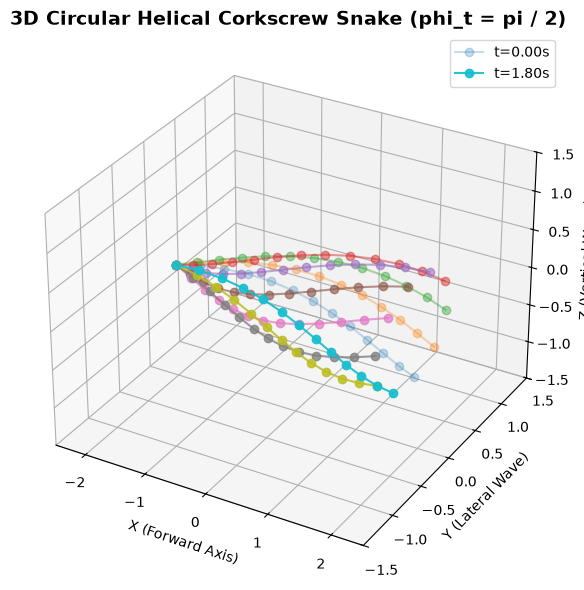

In [11]:
def get_joint_coords(armature, frame):
    _, pos_dict = compute_forward_kinematics(armature, frame)
    pts = [pos_dict[armature.bones_list[0].id][0]]
    for b in armature.bones_list:
        pts.append(pos_dict[b.id][1])
    return np.array(pts)

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('3D Circular Helical Corkscrew Snake (phi_t = pi / 2)', fontsize=14, fontweight='bold')
ax.set_xlabel('X (Forward Axis)')
ax.set_ylabel('Y (Lateral Wave)')
ax.set_zlabel('Z (Vertical Wave)')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)

sample_times = list(anim_dual.keys())[::3]
for idx, t in enumerate(sample_times):
    pts = get_joint_coords(armature, anim_dual[t])
    alpha = 0.25 + 0.75 * (idx / len(sample_times))
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], '-o', alpha=alpha, label=f't={t:.2f}s' if idx in [0, len(sample_times)-1] else '')

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Living Snake Interactive HTML5 Animation
Top-Down (X-Y) vs Side-View (X-Z) animation demonstrating the continuous 3D rotating motion across the full duration.

In [12]:
fig, (ax_top, ax_side) = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, xlabel, ylabel) in zip(
    [ax_top, ax_side],
    [("Top-Down View (X-Y Plane: Sine Wave)", "X (m)", "Y (m)"),
     ("Side View (X-Z Plane: Cosine Wave via phi_t=pi/2)", "X (m)", "Z (m)")]
):
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axvline(0, color='gray', linestyle=':', label='Center (x=0)')

line_top, = ax_top.plot([], [], '-o', color='#00d2d3', lw=3, label='Body (X-Y)')
line_side, = ax_side.plot([], [], '-o', color='#ff9f43', lw=3, label='Body (X-Z)')
ax_top.legend(loc='upper right')
ax_side.legend(loc='upper right')

timestamps = sorted(anim_dual.keys())

def update(frame_idx):
    t = timestamps[frame_idx]
    pts = get_joint_coords(armature, anim_dual[t])
    line_top.set_data(pts[:, 0], pts[:, 1])
    line_side.set_data(pts[:, 0], pts[:, 2])
    return line_top, line_side

anim = animation.FuncAnimation(fig, update, frames=len(timestamps), interval=60, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## 6. DQS Mesh Deformation & 3D Plotly Viewport
Bakes the segmented cylinder surface mesh with Dual Quaternion Skinning (DQS).

In [13]:
print('Baking 3D deformed mesh with Dual Quaternion Skinning (DQS)...')
baked_meshes = clip_dual.bake(mesh=mesh, skin_weights=skin_weights, method='dqs')
print(f'Successfully baked {len(baked_meshes)} 3D mesh frames.')

t_sample = sorted(baked_meshes.keys())[len(baked_meshes)//4]
m_frame = baked_meshes[t_sample]
v = m_frame.vertices
f = m_frame.faces

fig_3d = go.Figure()
fig_3d.add_trace(go.Mesh3d(
    x=v[:, 0], y=v[:, 1], z=v[:, 2],
    i=f[:, 0], j=f[:, 1], k=f[:, 2],
    color='#00d2d3', opacity=0.85, name=f'Circular Snake Skin (t={t_sample:.2f}s)',
    lighting=dict(ambient=0.6, diffuse=0.8, specular=0.4, roughness=0.3)
))

pts_skel = get_joint_coords(armature, anim_dual[t_sample])
fig_3d.add_trace(go.Scatter3d(
    x=pts_skel[:, 0], y=pts_skel[:, 1], z=pts_skel[:, 2],
    mode='lines+markers',
    line=dict(color='#ff9f43', width=7),
    marker=dict(size=6, color='#e74c3c'),
    name='Skeletal Bones'
))

fig_3d.update_layout(
    title='3D Deformed Snake with Circular Helical Waves (phi_t = pi / 2)',
    scene=dict(
        xaxis=dict(range=[-2.5, 2.5]),
        yaxis=dict(range=[-2.0, 2.0]),
        zaxis=dict(range=[-2.0, 2.0]),
        aspectmode='manual',
        aspectratio=dict(x=1.5, y=1.0, z=1.0)
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_3d.show()

Baking 3D deformed mesh with Dual Quaternion Skinning (DQS)...
Successfully baked 30 3D mesh frames.


## 7. Export to Valid Animated GLB
Exports the circular corkscrew snake to `generated_data/tests/circular_corkscrew_snake.glb` and `generated_data/steered_snake.glb`.

In [14]:
from animgen.io.glb_output import export_glb

base_dir = Path.cwd() if (Path.cwd() / 'animgen').exists() else Path.cwd().parent
out_dir = base_dir / 'generated_data' / 'animated'
out_dir.mkdir(parents=True, exist_ok=True)
out_glb = out_dir / 'circular_corkscrew_cylinder.glb'

export_glb(
    mesh=mesh,
    output_path=out_glb,
    armature=armature,
    skin_weights=skin_weights,
    animation=animator,
)
print(f'Exported animated cylinder with multiple clips {list(animator.keys())} to: {out_glb.resolve()}')


Exported animated cylinder with multiple clips ['TravellingCircularSnake', 'StandingCircularSnake'] to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/animated/circular_corkscrew_cylinder.glb
